In [1]:

import pandas as pd        
import numpy as np             
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve, classification_report, confusion_matrix
import joblib                  

train = pd.read_csv('D:\\DS Assignment\\Logistic Regression\\Logistic Regression\\Titanic_train.csv')
test = pd.read_csv('D:\\DS Assignment\\Logistic Regression\\Logistic Regression\\Titanic_test.csv')

train.shape, test.shape


((891, 12), (418, 11))

In [2]:
from IPython.display import display

print("===== First 20 rows (head) =====")
display(train.head(20))

print("\n===== Info =====")
train.info()   

print("\n===== Describe =====")
display(train.describe())

print("\n===== Missing values =====")
print(train.isnull().sum())


===== First 20 rows (head) =====


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C



===== Info =====
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB

===== Describe =====


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200



===== Missing values =====
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


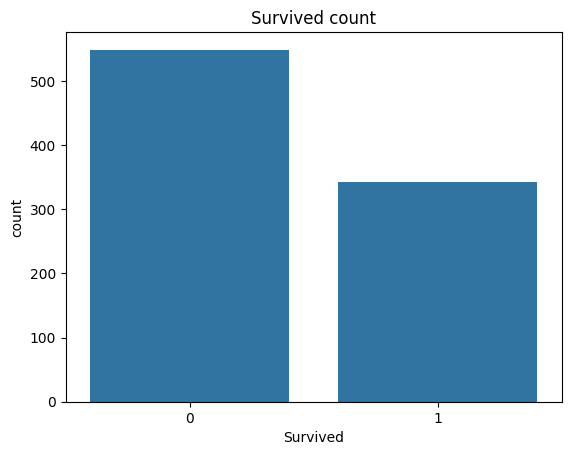

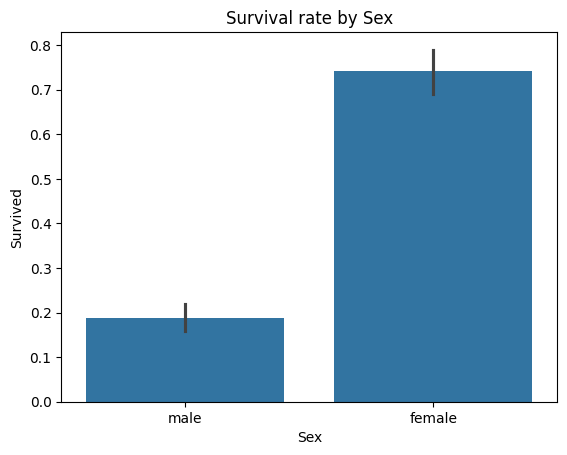

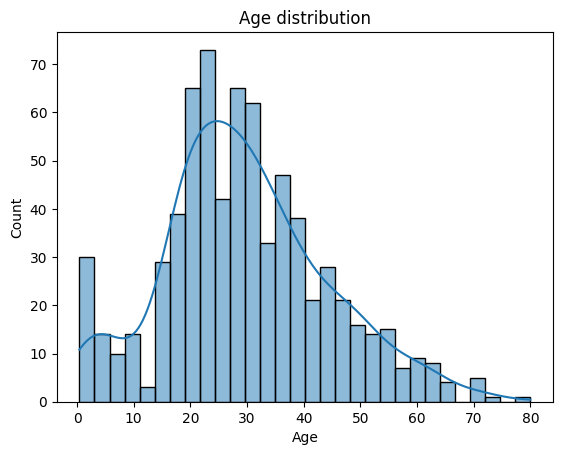

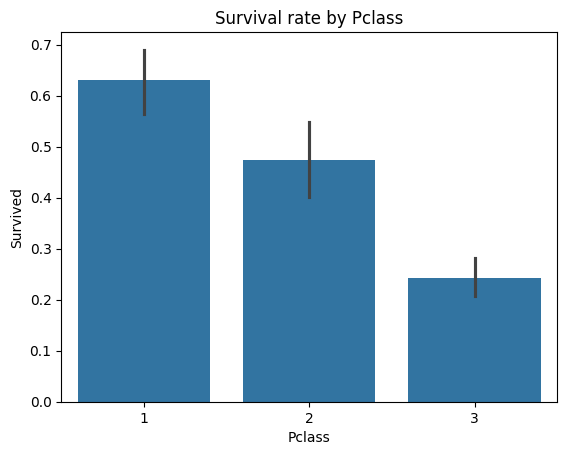

In [3]:
sns.countplot(x='Survived', data=train)
plt.title('Survived count')
plt.show()

sns.barplot(x='Sex', y='Survived', data=train)
plt.title('Survival rate by Sex')
plt.show()

sns.histplot(train['Age'].dropna(), bins=30, kde=True)
plt.title('Age distribution')
plt.show()

sns.barplot(x='Pclass', y='Survived', data=train)
plt.title('Survival rate by Pclass')
plt.show()


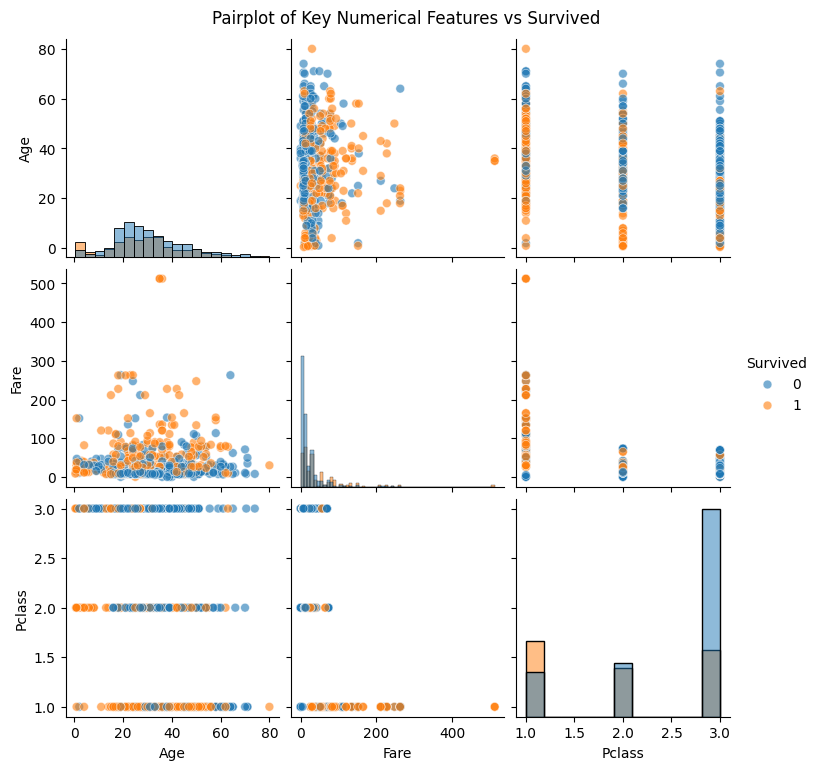

In [4]:
# === Pairplot for Numerical Variables ===

pair_cols = ['Age', 'Fare', 'Pclass', 'Survived']
sns.pairplot(train[pair_cols], hue='Survived', diag_kind='hist', plot_kws={'alpha':0.6, 's':40})
plt.suptitle("Pairplot of Key Numerical Features vs Survived", y=1.02)
plt.show()

###  Pairplot Observation
- The pairplot shows the distribution of `Age` and `Fare` across survived/non-survived classes.
- `Fare` shows a clearer separation than `Age`, indicating wealthier passengers had higher survival rates.
- `Pclass` shows distinct clusters, reinforcing its importance as a feature.

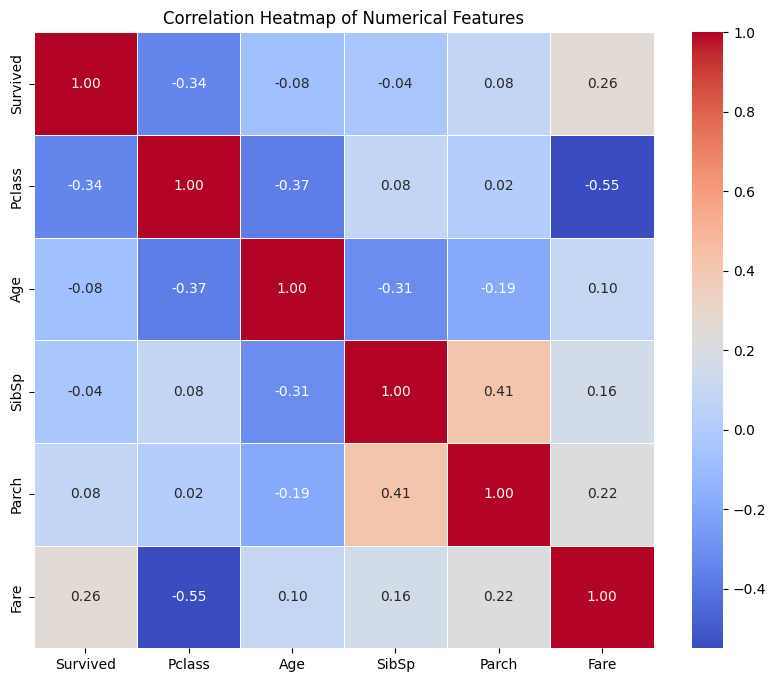

Key Correlations with Survived:
Survived    1.000000
Fare        0.257307
Parch       0.081629
SibSp      -0.035322
Age        -0.077221
Pclass     -0.338481
Name: Survived, dtype: float64


In [5]:

plt.figure(figsize=(10, 8))

num_cols = ['Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare']
corr_matrix = train[num_cols].corr()

sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title("Correlation Heatmap of Numerical Features")
plt.show()

print("Key Correlations with Survived:")
print(corr_matrix['Survived'].sort_values(ascending=False))

###  Correlation Analysis Insights
- **Sex (implicit via Pclass/Fare):** Although not directly in numeric heatmap, we know from EDA that Sex is highly correlated.
- **Pclass vs Survived:** Negative correlation (-0.34). Lower Pclass (1st class) has higher survival chances.
- **Fare vs Survived:** Positive correlation (0.26). Higher fare-paying passengers survived more.
- **Age vs Survived:** Weak negative correlation (-0.07). Younger passengers had a slight advantage.
- **SibSp/Parch:** Weak correlations, indicating family size alone isn't a strong predictor without feature engineering.

In [6]:
train = pd.read_csv('D:\\DS Assignment\\Logistic Regression\\Logistic Regression\\Titanic_train.csv').copy()
test  = pd.read_csv('D:\\DS Assignment\\Logistic Regression\\Logistic Regression\\Titanic_test.csv').copy()

age_median = train['Age'].median()
train['Age'] = train['Age'].fillna(age_median)
test['Age']  = test['Age'].fillna(age_median)   

emb_mode = train['Embarked'].mode()[0]
train['Embarked'] = train['Embarked'].fillna(emb_mode)
test['Embarked']  = test['Embarked'].fillna(emb_mode)

if test['Fare'].isnull().sum() > 0:
    fare_med = train['Fare'].median()
    test['Fare'] = test['Fare'].fillna(fare_med)

train['FamilySize'] = train['SibSp'] + train['Parch'] + 1
test['FamilySize']  = test['SibSp'] + test['Parch'] + 1

def get_title(name):
    if pd.isnull(name):
        return 'None'
    return name.split(',')[1].split('.')[0].strip()

train['Title'] = train['Name'].apply(get_title)
test['Title']  = test['Name'].apply(get_title)

rare_titles = train['Title'].value_counts()[train['Title'].value_counts() < 10].index.tolist()
train['Title'] = train['Title'].replace(rare_titles, 'Misc')
test['Title']  = test['Title'].replace(rare_titles, 'Misc')

drop_cols = ['PassengerId','Name','Ticket','Cabin']
train = train.drop(columns=[c for c in drop_cols if c in train.columns])
test  = test.drop(columns=[c for c in drop_cols if c in test.columns])


In [7]:
categorical_cols = ['Sex','Embarked','Title']

train = pd.get_dummies(train, columns=categorical_cols, drop_first=True)
test = pd.get_dummies(test, columns=categorical_cols, drop_first=True)

train, test = train.align(test, join='left', axis=1, fill_value=0)

X = train.drop('Survived', axis=1)
y = train['Survived']




In [8]:
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

X_train.shape, X_val.shape


((712, 13), (179, 13))

In [9]:

model = LogisticRegression(max_iter=1000) 
model.fit(X_train, y_train)


joblib.dump(model, 'logistic_titanic_joblib.pkl')



['logistic_titanic_joblib.pkl']

Accuracy: 0.8156424581005587
Precision: 0.7903225806451613
Recall: 0.7101449275362319
F1-score: 0.7480916030534351
ROC-AUC: 0.8718050065876153


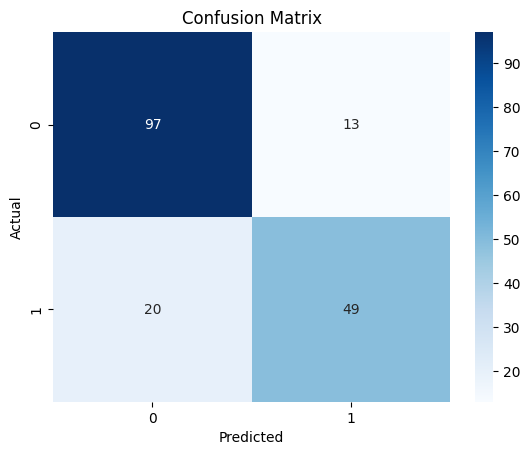

              precision    recall  f1-score   support

           0       0.83      0.88      0.85       110
           1       0.79      0.71      0.75        69

    accuracy                           0.82       179
   macro avg       0.81      0.80      0.80       179
weighted avg       0.81      0.82      0.81       179



In [10]:

y_pred = model.predict(X_val)
y_proba = model.predict_proba(X_val)[:,1] 

print("Accuracy:", accuracy_score(y_val, y_pred))
print("Precision:", precision_score(y_val, y_pred))
print("Recall:", recall_score(y_val, y_pred))
print("F1-score:", f1_score(y_val, y_pred))
print("ROC-AUC:", roc_auc_score(y_val, y_proba))

cm = confusion_matrix(y_val, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

print(classification_report(y_val, y_pred))


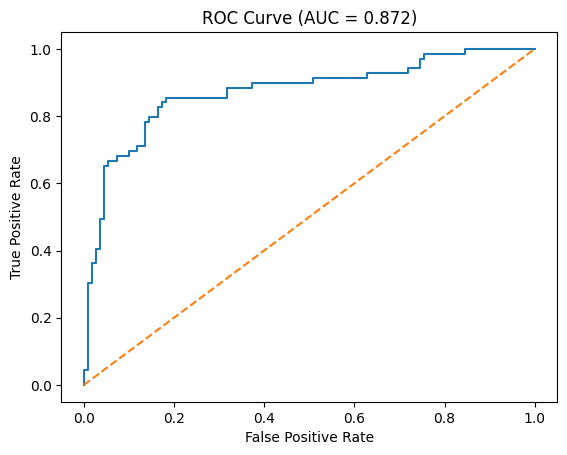

In [11]:
fpr, tpr, thresholds = roc_curve(y_val, y_proba)
plt.plot(fpr, tpr)
plt.plot([0,1],[0,1],'--')  # diagonal
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve (AUC = {:.3f})'.format(roc_auc_score(y_val, y_proba)))
plt.show()


In [12]:
coeffs = pd.Series(model.coef_[0], index=X_train.columns)
coeffs_sorted = coeffs.sort_values()
print("Top negative (reduce survival):")
print(coeffs_sorted.head(10))
print("\nTop positive (increase survival):")
print(coeffs_sorted.tail(10))

odds_ratios = np.exp(coeffs)
odds_ratios.sort_values().head(10), odds_ratios.sort_values().tail(10)


Top negative (reduce survival):
Title_Mr     -2.050813
Title_Misc   -1.034855
Pclass       -1.022139
Sex_male     -1.020236
Title_Miss   -0.386092
Embarked_S   -0.376892
FamilySize   -0.204737
SibSp        -0.169212
Parch        -0.056057
Age          -0.034612
dtype: float64

Top positive (increase survival):
Sex_male     -1.020236
Title_Miss   -0.386092
Embarked_S   -0.376892
FamilySize   -0.204737
SibSp        -0.169212
Parch        -0.056057
Age          -0.034612
Fare          0.003453
Embarked_Q    0.274617
Title_Mrs     0.367731
dtype: float64


(Title_Mr      0.128630
 Title_Misc    0.355278
 Pclass        0.359825
 Sex_male      0.360510
 Title_Miss    0.679708
 Embarked_S    0.685990
 FamilySize    0.814862
 SibSp         0.844330
 Parch         0.945485
 Age           0.965980
 dtype: float64,
 Sex_male      0.360510
 Title_Miss    0.679708
 Embarked_S    0.685990
 FamilySize    0.814862
 SibSp         0.844330
 Parch         0.945485
 Age           0.965980
 Fare          1.003459
 Embarked_Q    1.316026
 Title_Mrs     1.444454
 dtype: float64)

In [13]:

if 'Survived' in test.columns:
    test = test.drop(columns=['Survived'])
test = test.reindex(columns=X.columns, fill_value=0)
preds = model.predict(test)


In [14]:
test_raw = pd.read_csv('D:\\DS Assignment\\Logistic Regression\\Logistic Regression\\Titanic_test.csv')  

test_preds = model.predict(test)
submission = pd.DataFrame({
    'PassengerId': test_raw['PassengerId'],
    'Survived': test_preds
})
submission.to_csv('submission.csv', index=False)


###  Streamlit Deployment Instructions

To run the Titanic Survival Predictor app locally or deploy it:

1.  **Save the Code:** Copy the Streamlit code from the next cell and save it in a file named `app.py`.
2.  **Install Streamlit:** Open your terminal/command prompt and run:
    ```bash
    pip install streamlit scikit-learn pandas joblib
    ```
3.  **Run Locally:** Navigate to the folder containing `app.py` and run:
    ```bash
    streamlit run app.py
    ```
4.  **Deploy Online (Optional):**
    - Push your `app.py` and `logistic_titanic_joblib.pkl` to a GitHub repository.
    - Go to [Streamlit Community Cloud](https://share.streamlit.io/).
    - Connect your GitHub repo and deploy.

In [15]:

import streamlit as st
import joblib
import pandas as pd


model = joblib.load('logistic_titanic_joblib.pkl')

st.title("Titanic Survival Predictor (Logistic Regression)")


pclass = st.selectbox('Pclass', [1,2,3])
sex = st.selectbox('Sex', ['male','female'])
age = st.number_input('Age', min_value=0.0, max_value=100.0, value=30.0)
sibsp = st.number_input('SibSp', min_value=0, max_value=10, value=0)
parch = st.number_input('Parch', min_value=0, max_value=10, value=0)
fare = st.number_input('Fare', min_value=0.0, max_value=1000.0, value=32.0)
embarked = st.selectbox('Embarked', ['S', 'C', 'Q'])
title = st.selectbox('Title', ['Mr','Mrs','Miss','Master','Misc'])


input_df = pd.DataFrame({
    'Pclass':[pclass], 'Age':[age], 'SibSp':[sibsp], 'Parch':[parch], 'Fare':[fare],
    'FamilySize':[sibsp+parch+1]
})


for col in ['Sex_male','Embarked_Q','Embarked_S','Title_Misc','Title_Miss','Title_Mr','Title_Mrs','Title_Master']:
    input_df[col] = 0

if sex == 'male':
    input_df['Sex_male'] = 1
if embarked == 'Q':
    input_df['Embarked_Q'] = 1
elif embarked == 'S':
    input_df['Embarked_S'] = 1

title_col = 'Title_' + ('Misc' if title not in ['Mr','Mrs','Miss','Master'] else title)
if title_col in input_df.columns:
    input_df[title_col] = 1

if st.button('Predict'):
    prob = model.predict_proba(input_df)[:,1][0]
    st.write(f"Predicted survival probability: {prob:.2f}")
    st.write("Prediction:", "Survived" if prob > 0.5 else "Not survived")


2026-03-05 01:02:51.483 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-05 01:02:52.579 
  command:

    streamlit run C:\Users\SANSKAR\AppData\Roaming\Python\Python314\site-packages\ipykernel_launcher.py [ARGUMENTS]
2026-03-05 01:02:52.582 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-05 01:02:52.584 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-05 01:02:52.585 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-05 01:02:52.587 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-05 01:02:52.588 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-05 01:02:52.592 Th

###  Interview Questions & Answers

#### 1. What is the difference between Precision and Recall?
- **Precision:** Measures the accuracy of positive predictions. It answers: "Of all the instances predicted as positive, how many were actually positive?"
  - Formula: $Precision = \frac{TP}{TP + FP}$
  - Use Case: Important when False Positives are costly (e.g., Spam detection).
- **Recall (Sensitivity):** Measures the ability to find all positive instances. It answers: "Of all the actual positive instances, how many did we correctly predict?"
  - Formula: $Recall = \frac{TP}{TP + FN}$
  - Use Case: Important when False Negatives are costly (e.g., Cancer detection).

#### 2. What is Cross-Validation, and why is it important in binary classification?
- **Definition:** Cross-Validation (e.g., K-Fold) is a technique where the dataset is split into 'K' folds. The model is trained on K-1 folds and tested on the remaining fold, repeated K times.
- **Importance:**
  1.  **Prevents Overfitting:** Ensures the model generalizes well to unseen data.
  2.  **Better Performance Estimate:** Provides a more reliable estimate of model performance than a single train-test split.
  3.  **Data Efficiency:** Uses all data points for both training and validation across different iterations.